In [1]:
%load_ext autoreload
%autoreload 2

## Estimating pos, lin vel, ang vel and contact force - with payload on robot

With added payload on the robot's base.

In [22]:
from pathlib import Path
from utils.kf_utils import load_custom_dataset
from utils.run_estimation import run_state_estimation
from utils.plot_data import *

sim_num = 2
dataset_num = 1
data = load_custom_dataset(
    dataset_path=Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz", 
    sim_num=sim_num)

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run1.npz.


In [8]:
for i in range(0,5):
    data = load_custom_dataset(
        dataset_path=Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run1.npz", 
        sim_num=i)
    print(data["base_mass"][0])

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run1.npz.
13.863770123928726
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run1.npz.
10.243513451832786
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run1.npz.
16.025259614735266
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run1.npz.
12.18877118025442
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run1.npz.
15.300905384864222


In [10]:
start = 0
end = len(data["dt"])

result = run_state_estimation(dt=data["dt"][0],
                              base_orient=data["base_orient"],
                              base_ang_vel=data["base_ang_vel"],
                              joint_pos=data["joint_pos"],
                              joint_vel=data["joint_vel"],
                              joint_acc=data["joint_acc"],
                              joint_torque=data["joint_torque"],
                              contact_states=data["contact_states"],
                              Q=[0.0001, 0.0001, 0.0001, 0.001],
                              R=[0.1, 0.1, 0.0001, 0.01],
                              est_mode=4)

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Running state estimation:  33%|███▎      | 165/500 [00:00<00:00, 824.31it/s]

Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 500/500 [00:00<00:00, 769.80it/s]


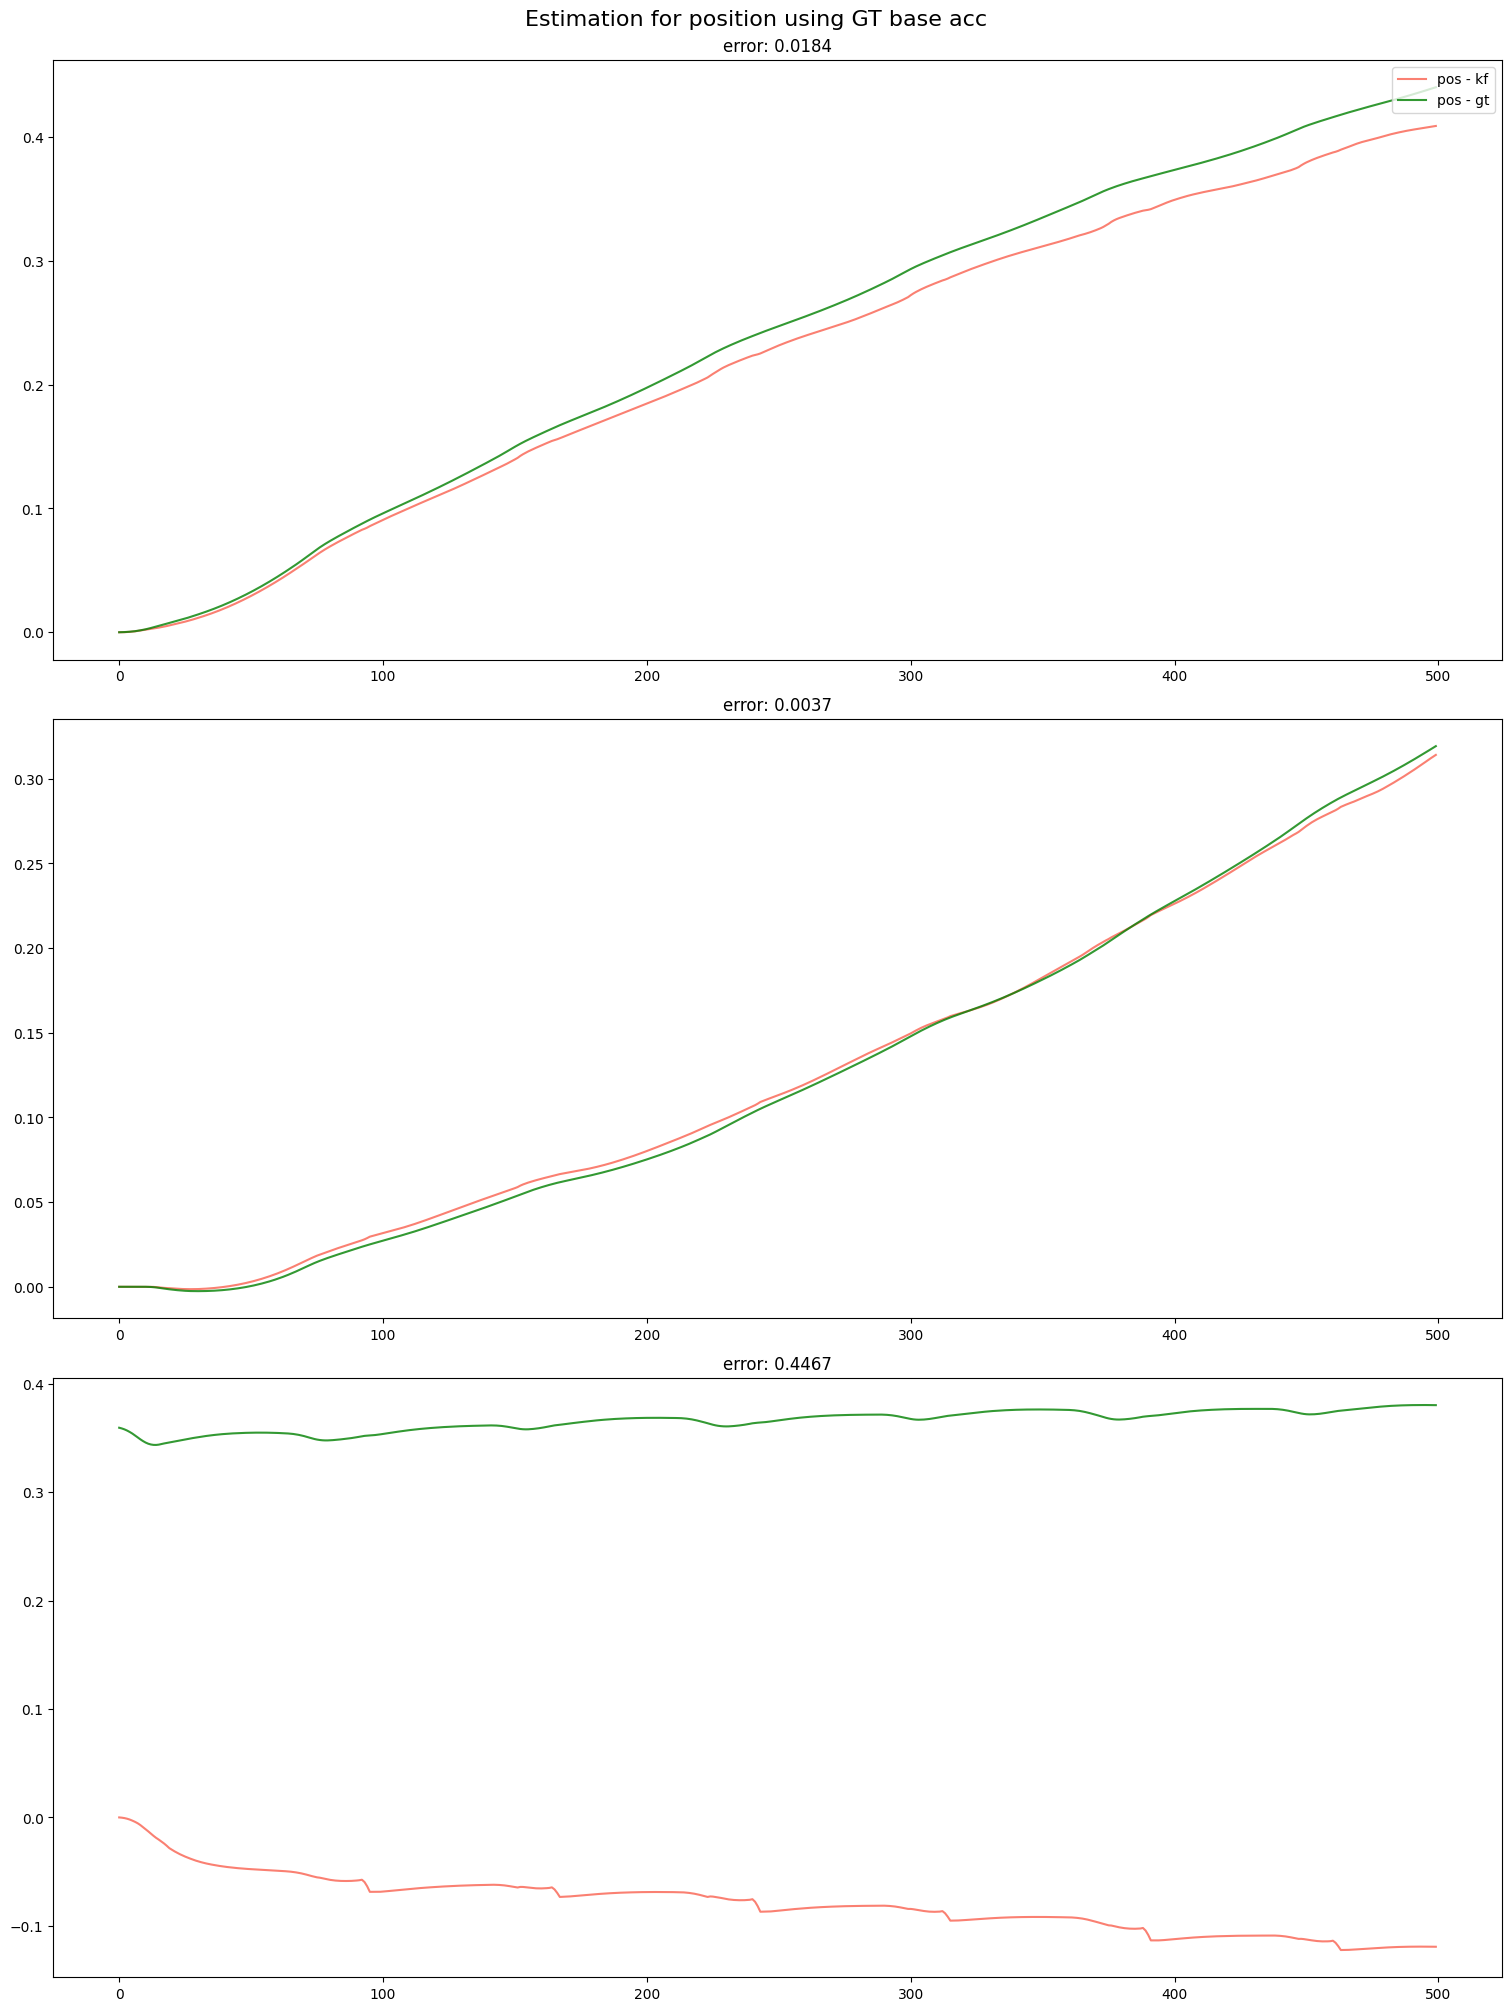

In [11]:
estimation_plot(gt_value=data["base_pos"],
                est_value=result["pos_update"],
                label="pos",
                title="Estimation for position using GT base acc")

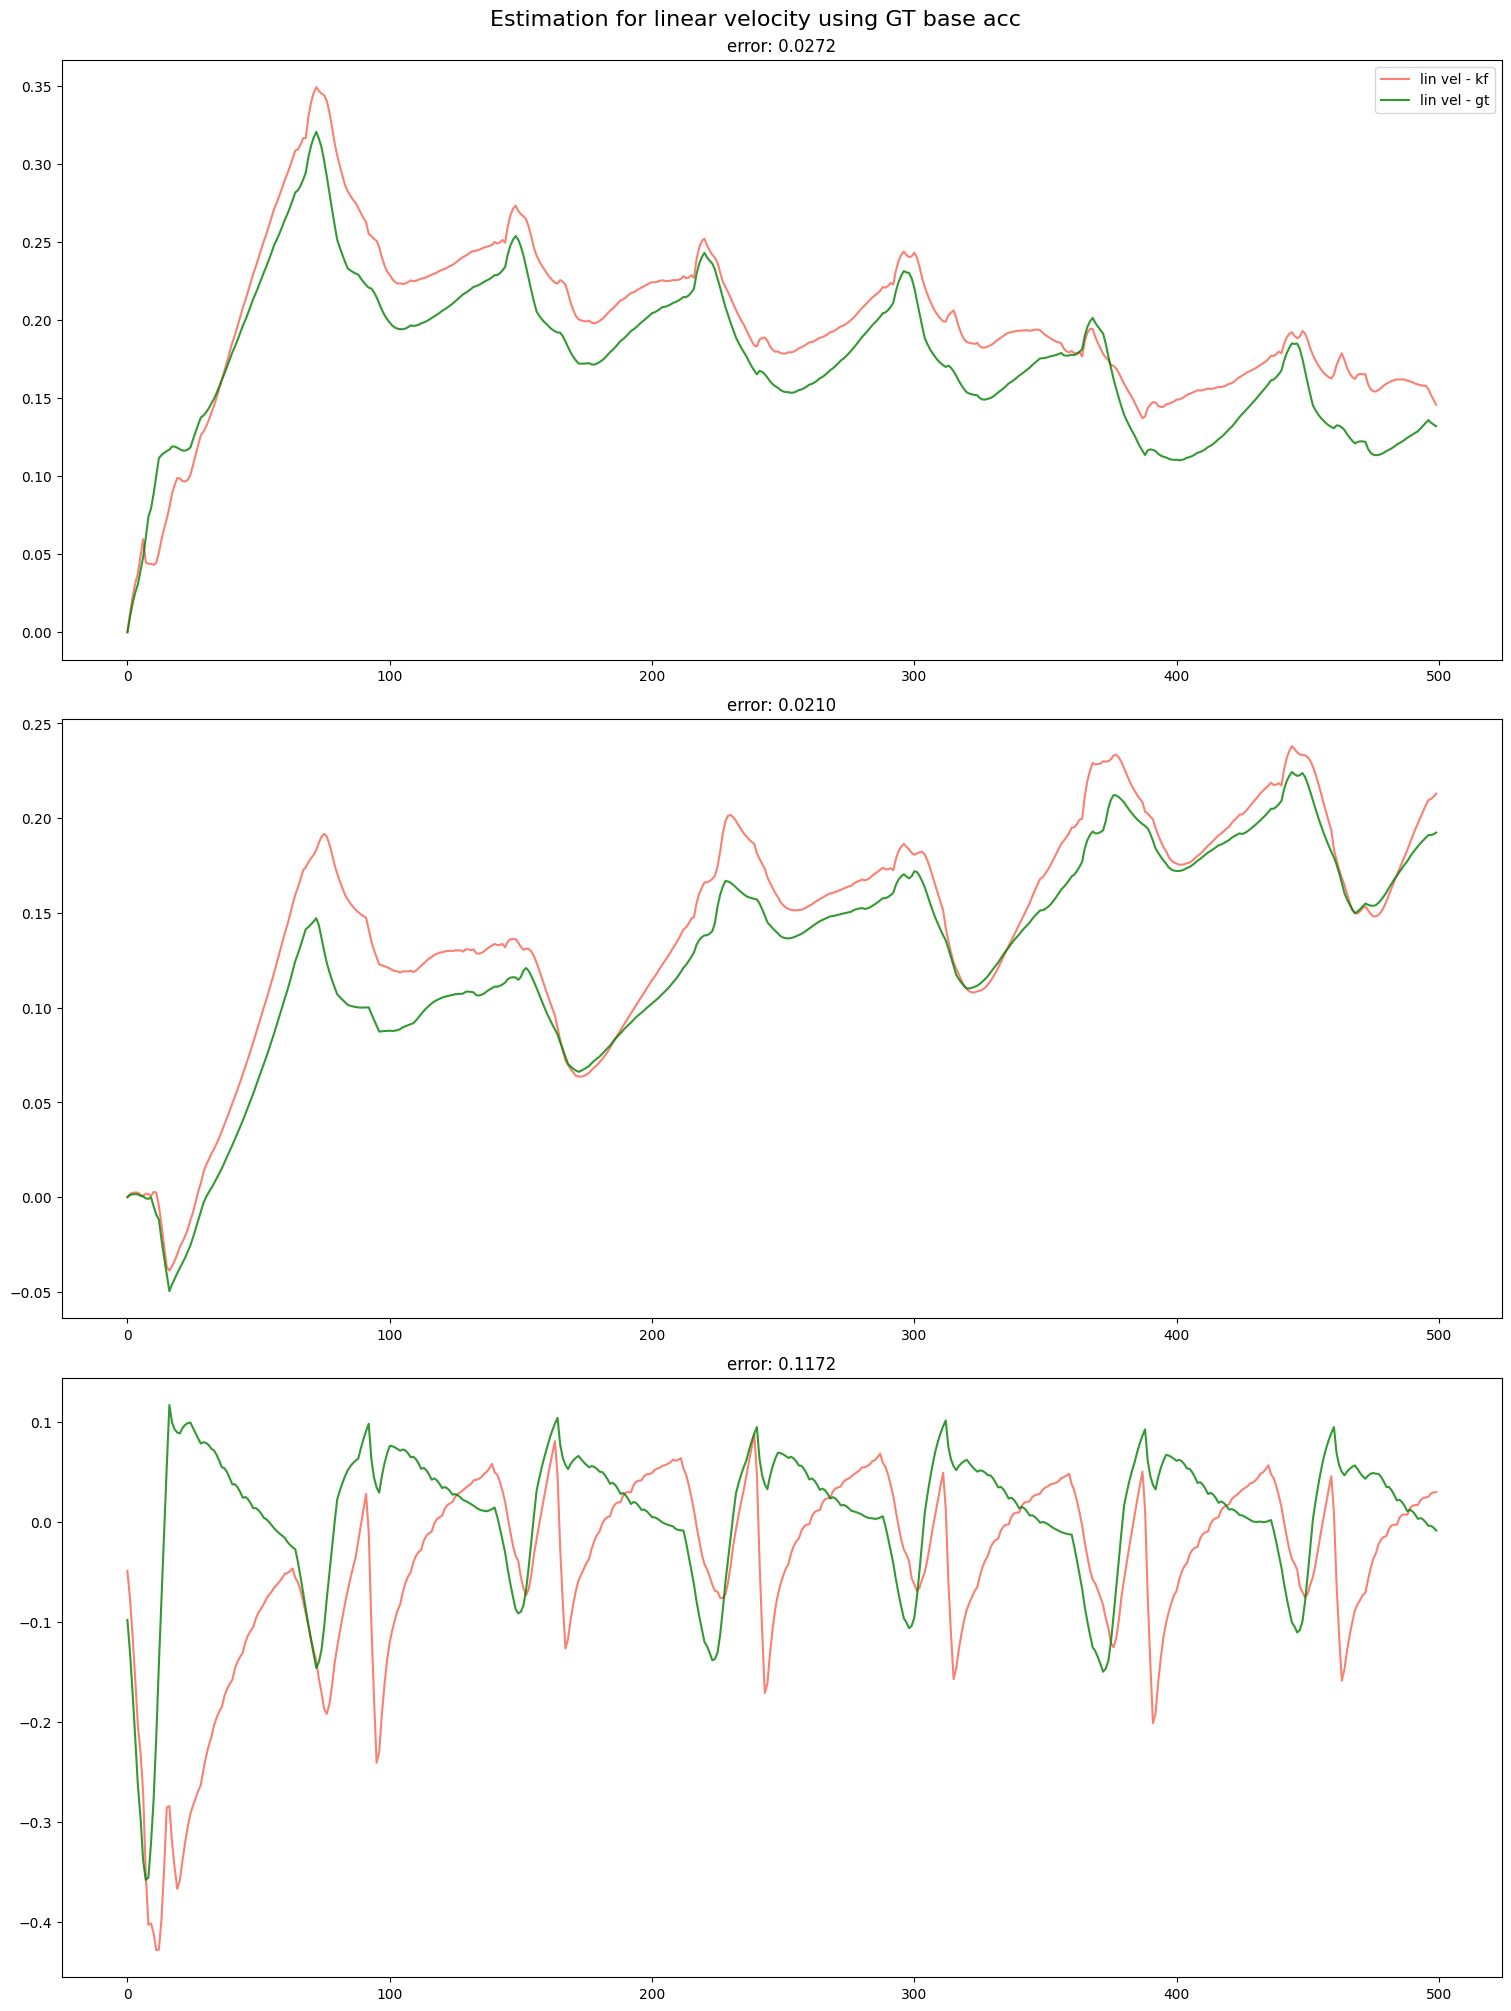

In [12]:
estimation_plot(gt_value=data["base_vel"],
                est_value=result["vel_update"],
                label="lin vel",
                title="Estimation for linear velocity using GT base acc")

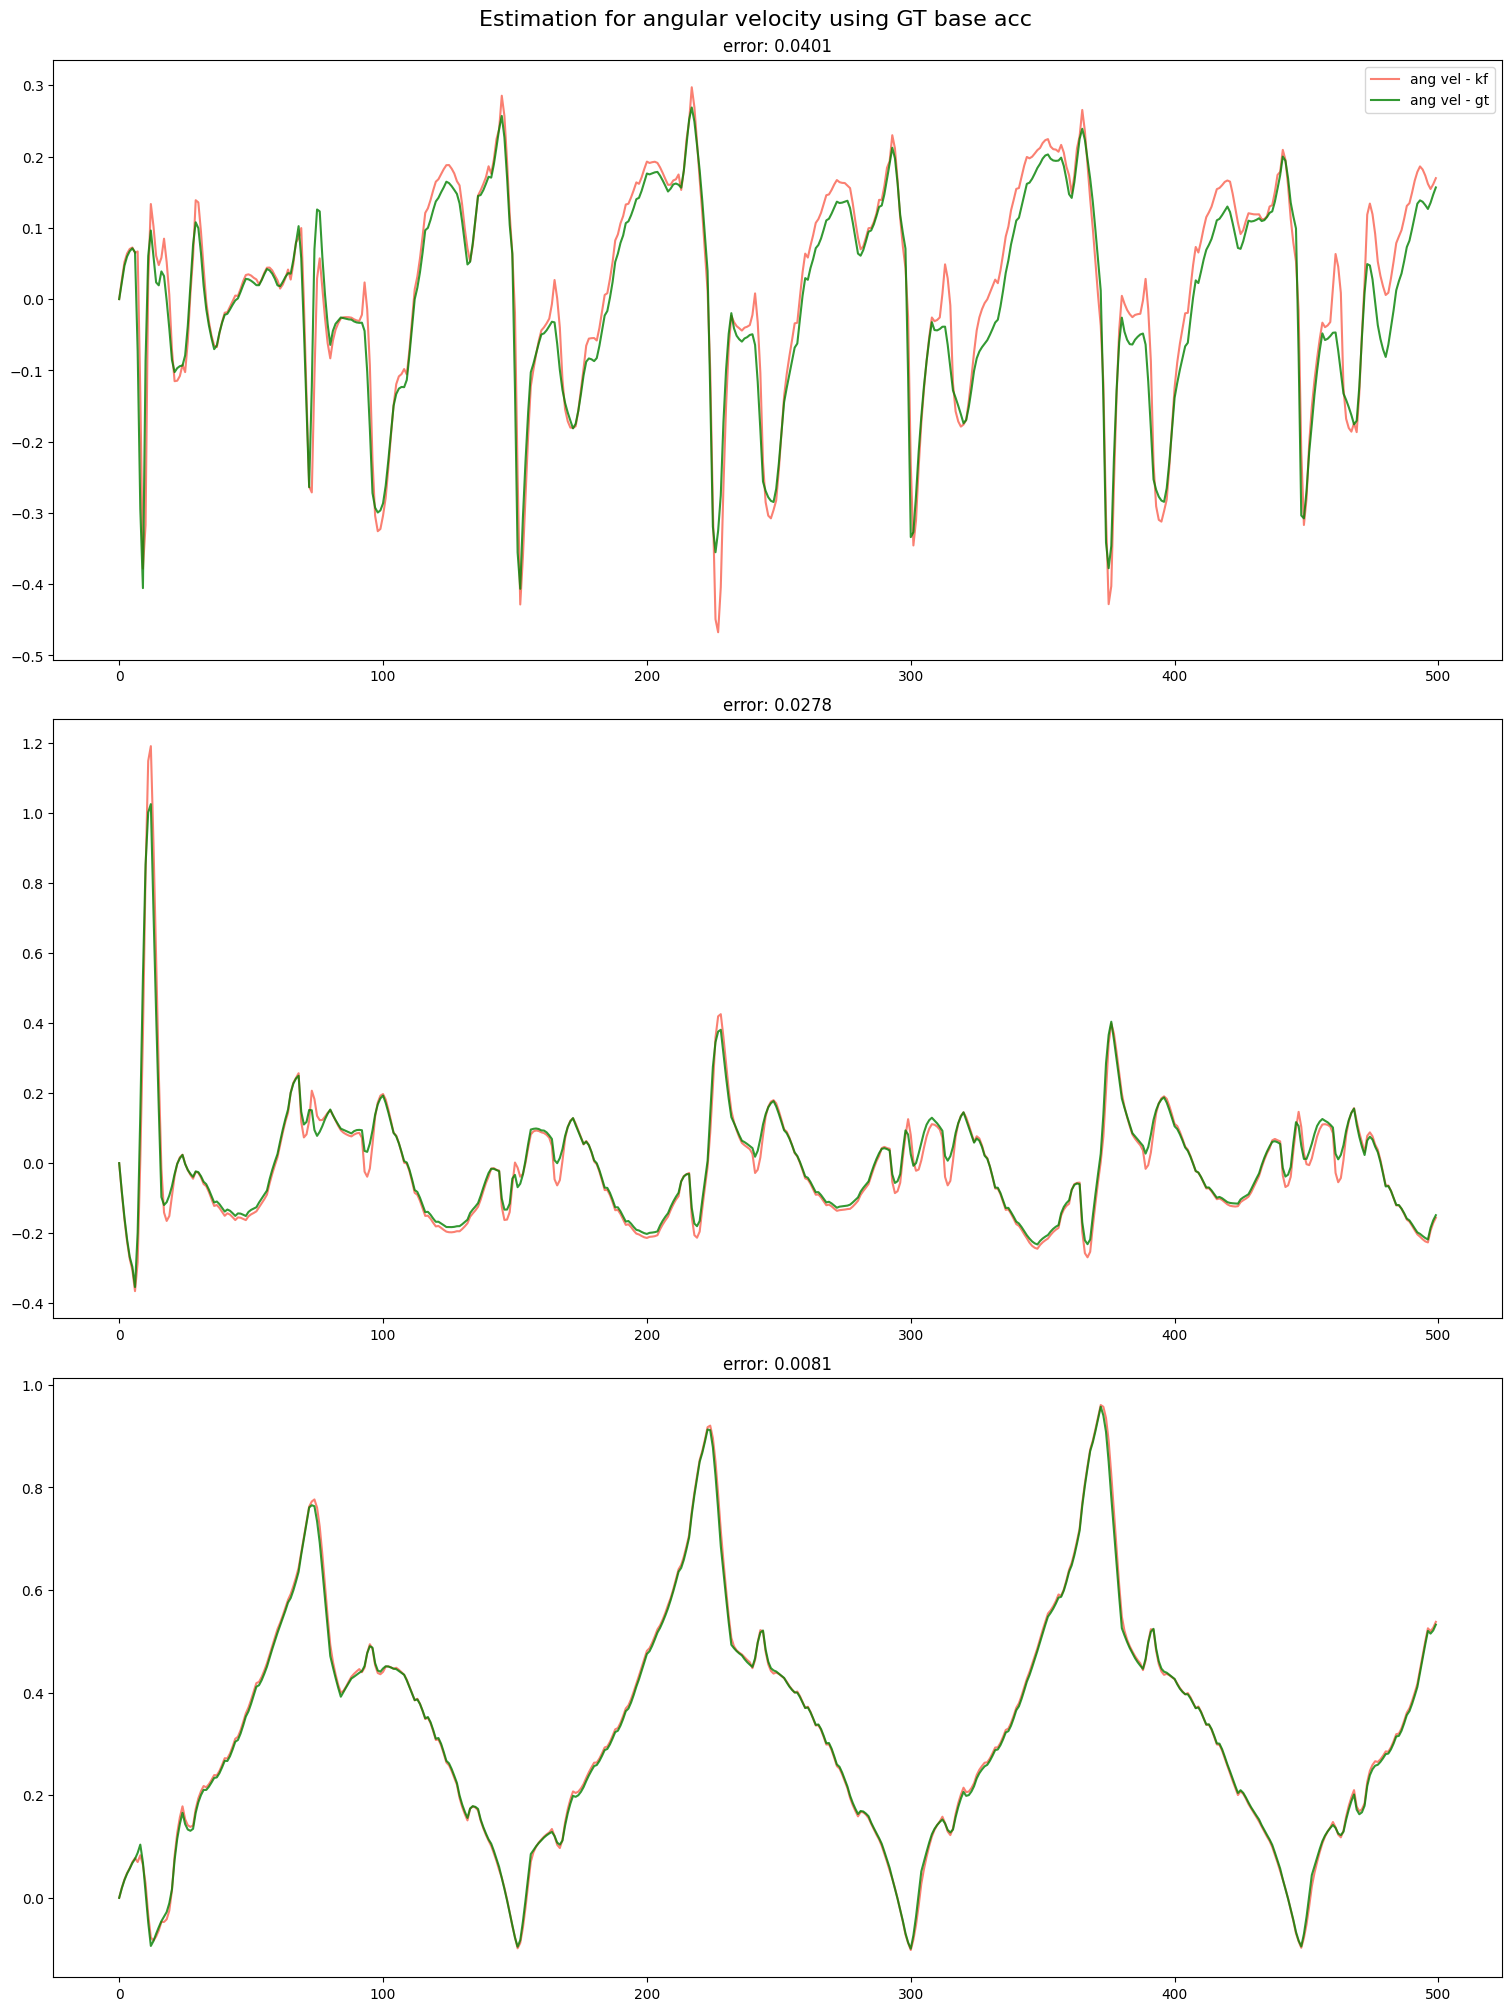

In [13]:
estimation_plot(gt_value=data["base_ang_vel"],
                est_value=result["ang_vel_update"],
                label="ang vel",
                title="Estimation for angular velocity using GT base acc")

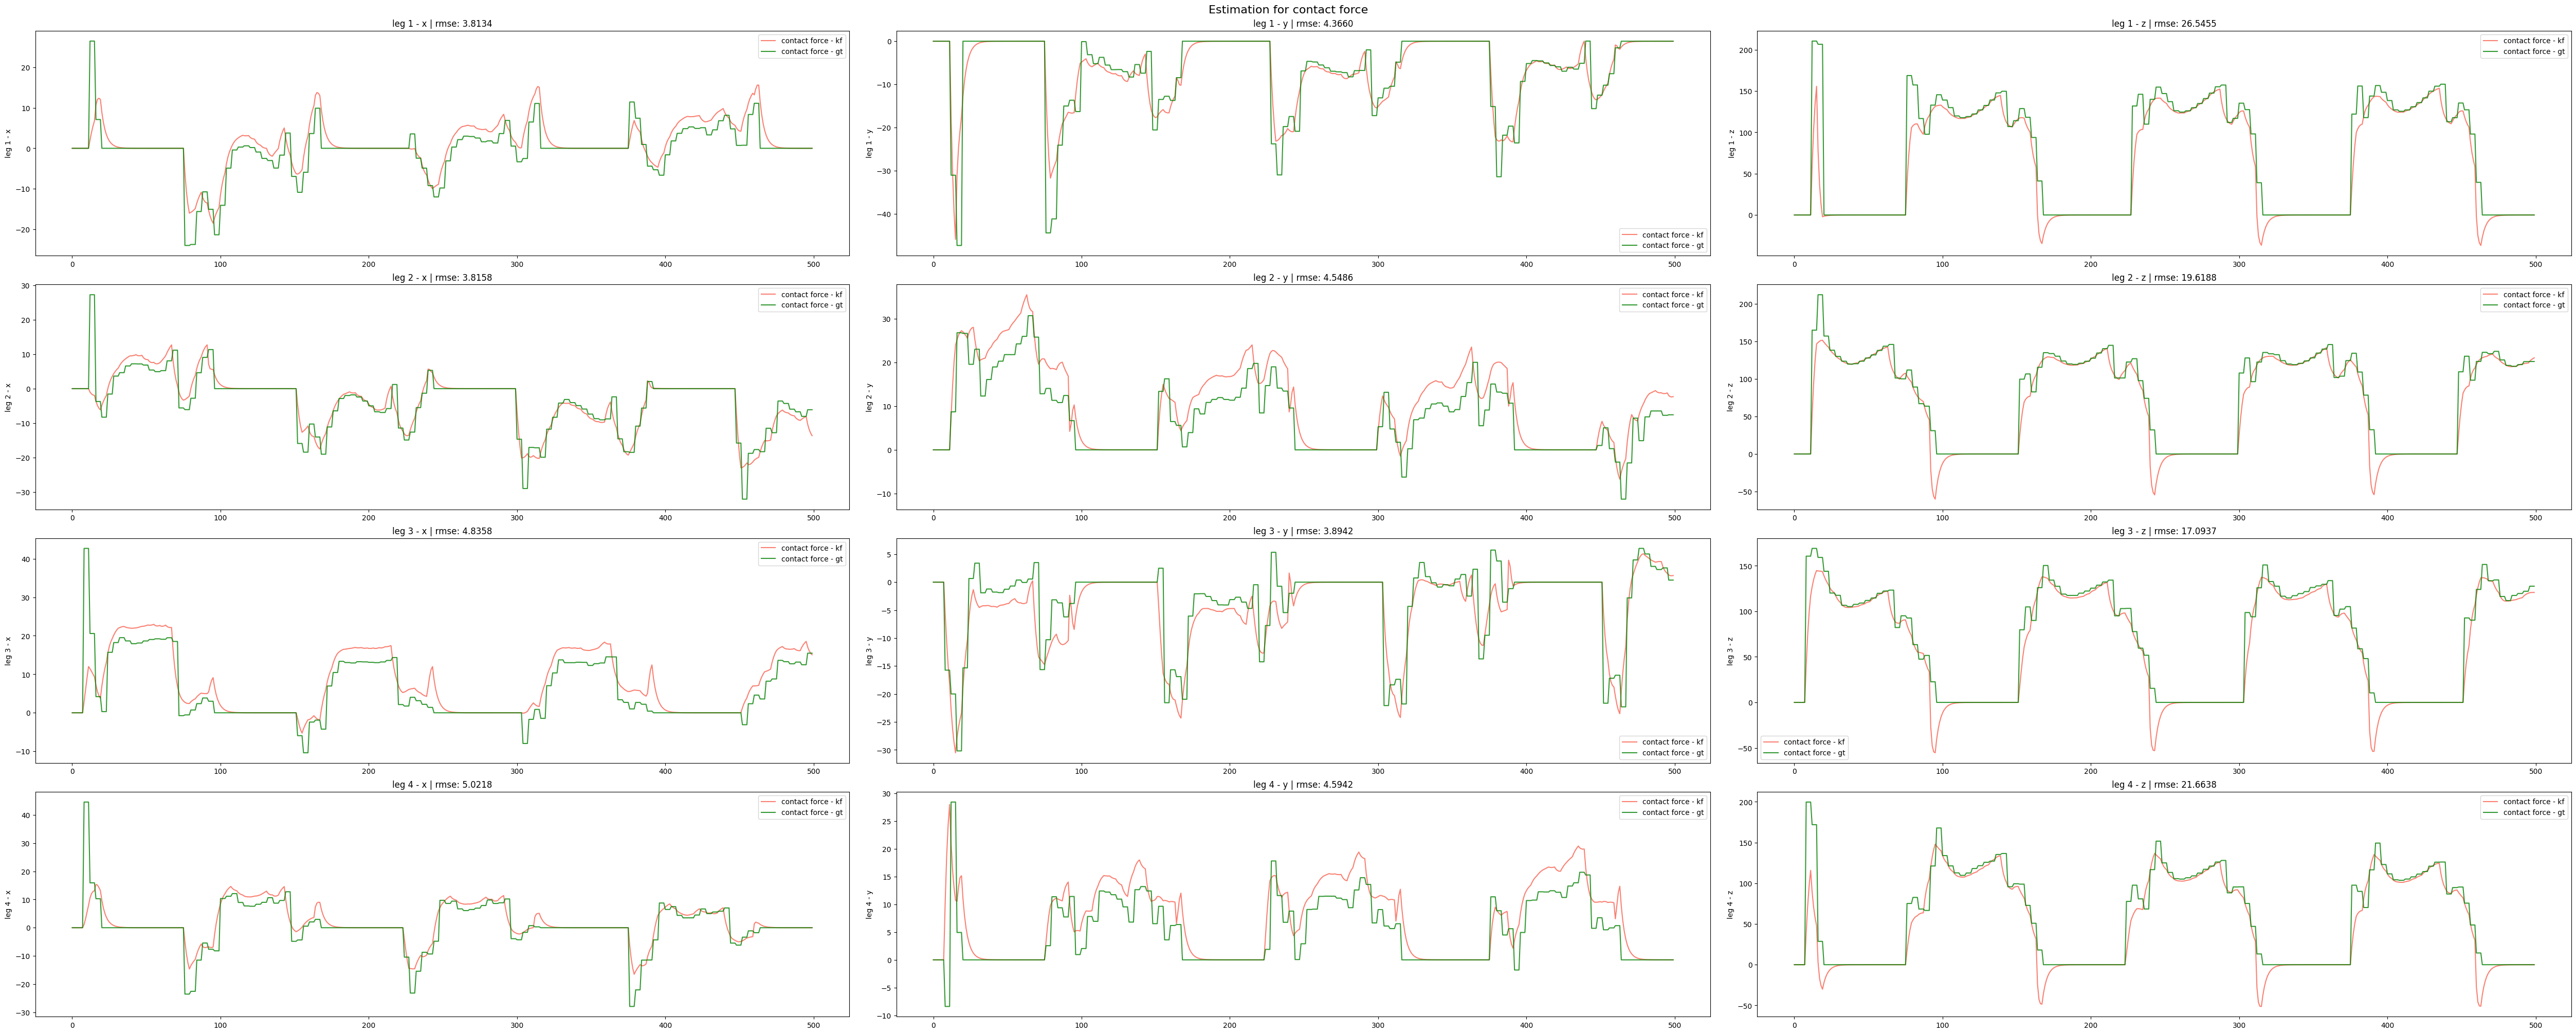

In [14]:
force_estimation_plot(gt_value=data["contact_forces"],
                      est_value=result["c_force_update"],
                      label="contact force",
                      start=0,
                      end=500,
                      title="Estimation for contact force")

## LSTM

Window sequence is defined by $n_h$.

Input:
- joint position $q$
- joint velocity $\dot{q}$
- residual torque $\tilde{\tau_i} = \tau_i - \hat{\tau_i}$

Output:
- latent representation with dim 10
- prediction for torque (?)

In [79]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

from utils.lstm_context_encoder import ContextEncoderLSTM, create_lstm_dataset

### Dataset preparation

In [80]:
dataset_num = 5
dataset_path = f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz"

# data = load_custom_dataset(dataset_path=Path.cwd().parent / dataset_path, sim_num=1)
X_train, y_train = create_lstm_dataset(dataset_path=dataset_path, n_h=15)

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run5.npz.


Creating train dataset: 100%|██████████| 25/25 [00:00<00:00, 289.46it/s]


### Training

In [81]:
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

input_size = 12 + 12 + 6 # q, qdot, tau_tilde
model = ContextEncoderLSTM(input_size=input_size, z_dim=6, hidden_size=10, num_layers=5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

num_epochs = 100
log_step = 10
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % log_step == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(loader):.6f}')

Epoch [10/100], Loss: 7.801464
Epoch [20/100], Loss: 6.119741
Epoch [30/100], Loss: 5.220913
Epoch [40/100], Loss: 4.764201
Epoch [50/100], Loss: 4.470064
Epoch [60/100], Loss: 4.286005
Epoch [70/100], Loss: 4.162791
Epoch [80/100], Loss: 4.067978
Epoch [90/100], Loss: 3.940915
Epoch [100/100], Loss: 3.926089


### Evaluation

norm_tau for joint 1: 6.6123	RMSE for joint 1: 0.9289
norm_tau for joint 2: 6.2955	RMSE for joint 2: 0.9884
norm_tau for joint 3: 385.5660	RMSE for joint 3: 0.0243
norm_tau for joint 4: 1.9591	RMSE for joint 4: 0.4813
norm_tau for joint 5: 2.7471	RMSE for joint 5: 0.2858
norm_tau for joint 6: 0.0887	RMSE for joint 6: 0.9821


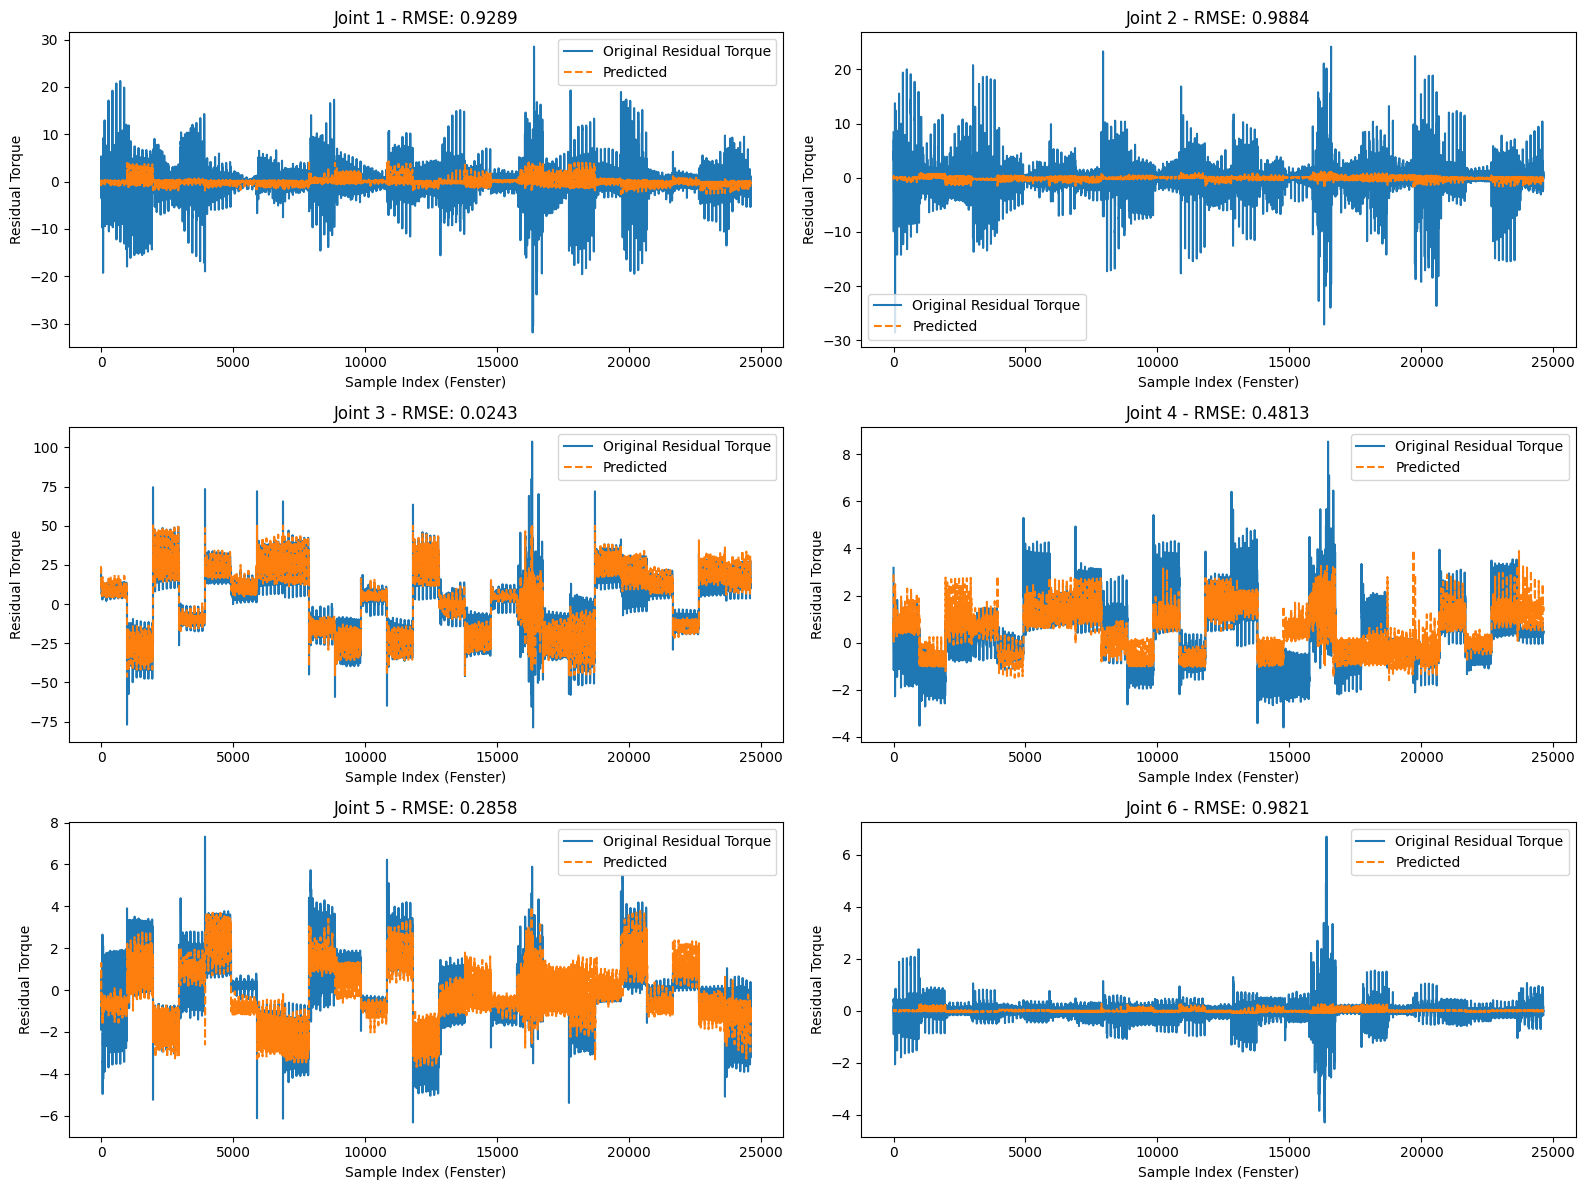

In [82]:
model.eval()
with torch.no_grad():
    predicted = model(X_train)

predicted = predicted.numpy()
original = y_train.numpy()

num_joints = original.shape[1]

norm_tau = np.var(original,axis=0)
err_tau = 1. / float(original.shape[0]) * np.sum((predicted - original) ** 2 / norm_tau, axis=0)

for i in range(num_joints):
    print(f"norm_tau for joint {i+1}: {norm_tau[i]:.4f}\tRMSE for joint {i+1}: {err_tau[i]:.4f}")

time_steps = np.arange(len(original))

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for joint_idx in range(num_joints):
    ax = axes[joint_idx]
    ax.plot(time_steps, original[:, joint_idx], label='Original Residual Torque')
    ax.plot(time_steps, predicted[:, joint_idx], label='Predicted', linestyle='--')
    ax.set_title(f'Joint {joint_idx+1} - RMSE: {err_tau[joint_idx]:.4f}')
    ax.set_xlabel('Sample Index (Fenster)')
    ax.set_ylabel('Residual Torque')
    ax.legend()

plt.tight_layout()
plt.show()